## Image Classification by Using CNN Model
Exercise: 1

In this exercise, we will build a classifier model from scratch that is able to distinguish objects from the dataset.

We will follow these steps:

1. Explore the dataset.
2. Understand the shape of the image arrays.
3. Visualising Sample Imagees from the dataset.
4. Building the Convolutional Neural Network (CNN).
5. Evaluating the trained model

Let's go!

**LIBRARIES:** This cell imports the **main libraries** used for image classification with a CNN — **TensorFlow** (for building and training the model), **Matplotlib** (for plotting images), and **NumPy** (for numerical operations).

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.image import resize
import numpy as np

# 1. Explore the Dataset
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
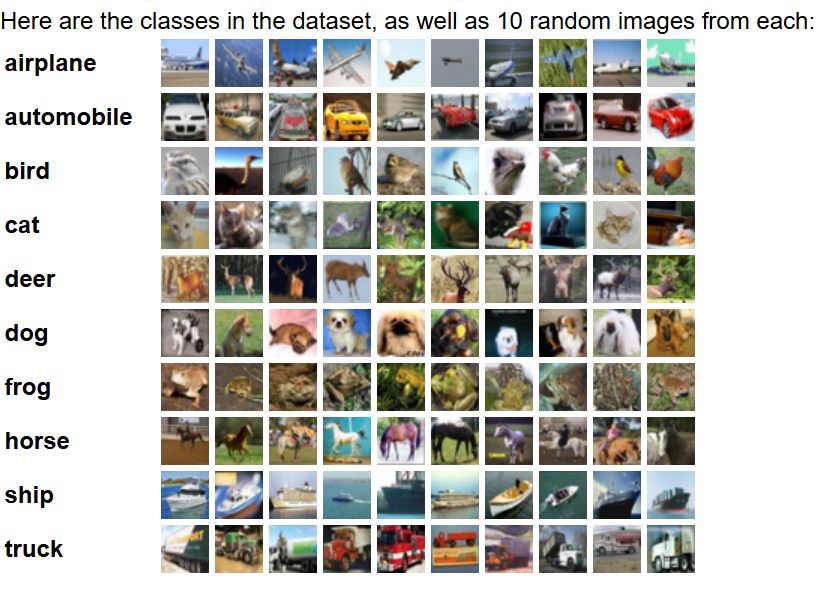


In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

# 2. Understanding the shape and reshaping the images.
The **shape** and sample values of the training and test sets to understand the dataset structure. It ensures the data is loaded correctly and helps visualise what the input and label arrays look like.

In [ ]:
X_test.shape

(10000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
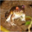

In [ ]:
X_train[0]

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,) #flaten into 1 dimentional array
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [ ]:
classes[2]

'bird'

# 3. Visualising the loaded images.
This cell displays several random images from the CIFAR-10 training dataset to help visualise what the images look like and confirm they’re loaded correctly.

In [ ]:
def plot_sample(X, y, index):
  plt.figure(figsize= (15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

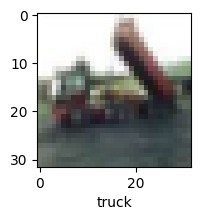

In [ ]:
plot_sample(X_train, y_train, 2)

# 4. Normalising the Pixel Values.
Pixel values in CIFAR-10 range from 0 to 255. Normalizing (scaling between 0 and 1) helps the neural network train faster and perform better.

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
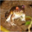

In [ ]:
X_train[0]

In [ ]:
# Normalizing data
X_train = X_train / 255
X_test = X_test / 255

# 5. Feed the Model
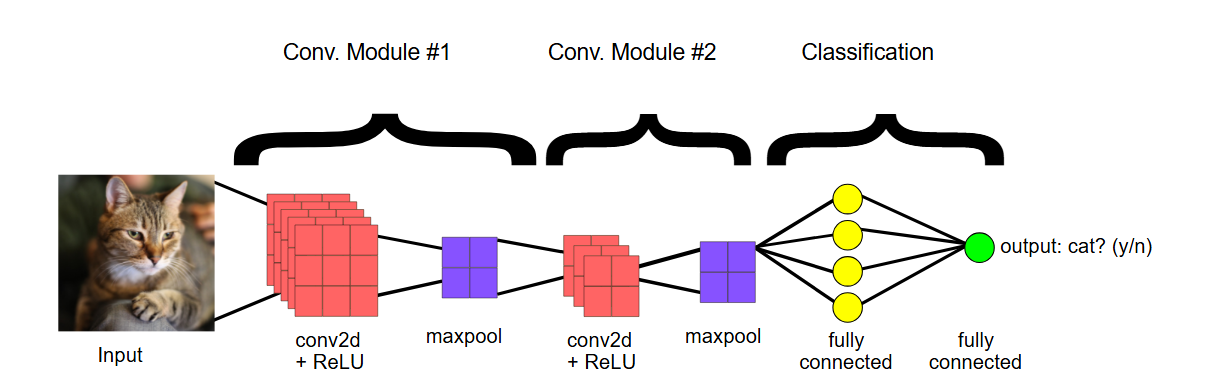

# Stride
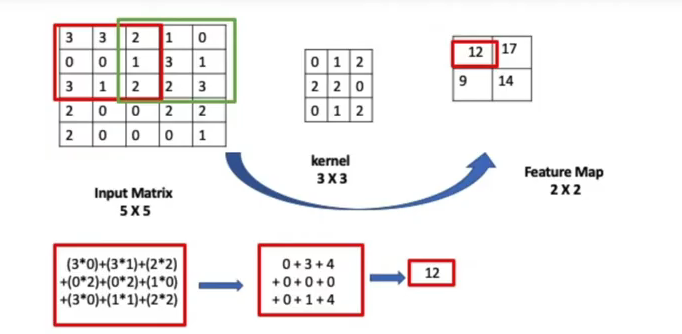


Stride in a convolutional neural network is the number of pixels the filter (or kernel) moves across the input data in each step. A stride of \(1\) means the filter moves one pixel at a time, creating a smaller output map and preserving high spatial resolution.

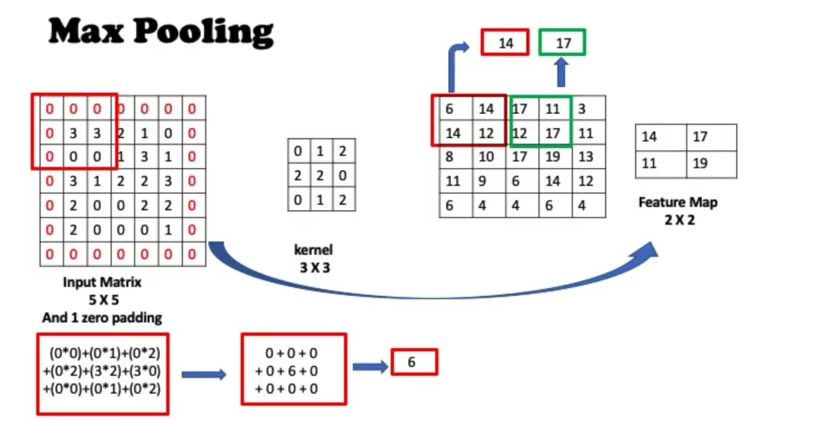

Max pooling is a downsampling technique in a convolutional neural network (CNN) that reduces the spatial dimensions of a feature map by selecting the maximum value from a defined region.

In [ ]:
# Initialises a sequential model — layers are stacked one after another.
cnn = models.Sequential([


                #Adds a 2D convolutional layer, 32 filters (feature detectors), Each filter is 3×3, activation='relu' introduces nonlinearity
                # input_shape=(32,32,3) tells the model the input image size.
                layers.Conv2D(filters=32, kernel_size=(3,3), activation= 'relu', input_shape=(32,32,3)),

                # Adds a max pooling layer to reduce the spatial dimensions by half (from 32×32 → 16×16). Helps reduce computation and overfitting.
                layers.MaxPooling2D((2,2)),

                #Adds another convolutional layer with 64 filters (for more feature depth).
                layers.Conv2D(filters=32, kernel_size=(3,3), activation= 'relu', input_shape=(32,32,3)),

                #Another pooling layer (reduces spatial size again).
                layers.MaxPooling2D((2,2)),


                #Converts the 3D feature maps (from convolutional layers) into a 1D vector so they can be fed into dense (fully connected) layers.
                layers.Flatten(),
                layers.Dense(64, activation='relu'),
                layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 6. Compiling the CNN model.
This step configures how the model will learn, it defines the optimizer, loss function, and evaluation metrics.

In [ ]:
cnn.compile(optimizer='adam', #Uses the Adam optimizer, a popular algorithm combining momentum and adaptive learning rates for efficient training.
              loss='sparse_categorical_crossentropy', #Sets the loss function
              metrics=['accuracy']) #Tracks model accuracy during training and evaluation.

# 7. Training the CNN model
Fit function () trains the model using the training dataset and validates it on the test dataset. It also stores training history for later visualization.

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.3665 - loss: 1.7301
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.5658 - loss: 1.2252
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.6234 - loss: 1.0731
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.6561 - loss: 0.9764
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6746 - loss: 0.9276
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6937 - loss: 0.8780
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.7108 - loss: 0.8327
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.7217 - loss: 0.7890
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7345 - loss: 0.7627
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.7463 - loss: 0.7245


# 8. Evaluating the trained model
After training, this cell evaluates the model’s performance on the test set, providing loss and accuracy metrics.


In [ ]:

cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6909 - loss: 0.9065


[0.9053980708122253, 0.6930000185966492]

In [ ]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

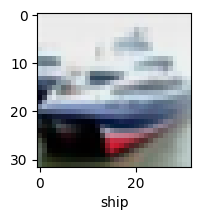

In [ ]:
plot_sample(X_test, y_test, 1)

# Train Prediction

In [ ]:
#The CNN predicts values for all test inputs
y_pred = cnn.predict(X_test)
y_pred[:5]  #shows the predictions for the first 5 test samples only.


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[1.4669643e-04, 6.1358069e-03, 5.0311135e-03, 8.9743209e-01,
        1.3975590e-03, 6.2947996e-02, 1.4606217e-02, 7.3854819e-05,
        9.4428621e-03, 2.7857386e-03],
       [6.5848306e-03, 4.1477641e-01, 5.5856299e-06, 1.8754579e-07,
        3.7845336e-08, 3.9525161e-09, 2.9292169e-08, 9.3240251e-09,
        5.7703042e-01, 1.6024977e-03],
       [3.4264352e-02, 7.0296661e-03, 1.2811078e-04, 2.2710161e-04,
        4.1389052e-05, 8.6700411e-06, 5.9716072e-05, 8.2483384e-06,
        9.5660371e-01, 1.6289968e-03],
       [7.1288925e-01, 4.8312275e-03, 1.7340155e-01, 9.6245739e-04,
        2.2039989e-02, 5.4582171e-05, 2.0706771e-02, 4.6972025e-05,
        6.4627208e-02, 4.3981403e-04],
       [1.3407439e-05, 8.4169287e-06, 3.2199658e-02, 2.8316161e-02,
        4.1404435e-01, 2.5051434e-02, 4.9980280e-01, 5.1578798e-04,
        4.3034564e-05, 4.8692077e-06]], dtype=float32)

In [ ]:
# It loops through every element (prediction) in y_pred and applies np.argmax to each.
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]  # This shows the first 5 predicted class labels.

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]


# 9. Model Testing & Prediction



In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

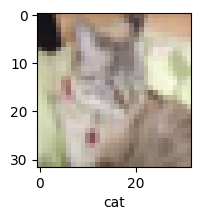

In [ ]:

plot_sample(X_test, y_test, 8)

In [ ]:
classes[y_classes[8]] #Compare with the y class to check the accuracy

'cat'

# Exercise: 2
# **Cat VS Dog Classification

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [ ]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=_URL, extract=True)
base_dir = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
